# Klasyfikacja kierunku ceny akcji v3 (selekcja cech + strojenie progu neutralnego)

Ten notebook to kolejny eksperyment po v1/v2:
- siec MLP na mniejszym, wybranym zbiorze cech,
- selekcja cech przez mutual information,
- strojenie progu decyzyjnego dla klasy `bez_zmian`,
- walidacja czasowa i test na ostatnich 2 miesiacach.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
TEST_MONTHS = 2
CLASS_ORDER = ["spadek", "bez_zmian", "wzrost"]
CLASS_CODE_ORDER = [0, 1, 2]


In [2]:
data_root = next((p for p in [Path("../data/equity_data"), Path("data/equity_data")] if p.exists()), None)
if data_root is None:
    raise FileNotFoundError("Brak katalogu data/equity_data")
model_dir = data_root / "model_data"
model_dir.mkdir(parents=True, exist_ok=True)

lagged_candidates = [
    model_dir / "stock_direction_dataset_v2_lagged_best.csv",
    model_dir / "stock_direction_dataset_lagged.csv",
]
lagged_path = next((p for p in lagged_candidates if p.exists()), None)
if lagged_path is None:
    raise FileNotFoundError("Nie znaleziono lagged datasetu. Uruchom najpierw notebook v1 lub v2.")

df = pd.read_csv(lagged_path)
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date", "y_code"]).sort_values("date").reset_index(drop=True)
df["y_code"] = pd.to_numeric(df["y_code"], errors="coerce").astype("Int64")
df = df[df["y_code"].notna()].copy()
df["y_code"] = df["y_code"].astype(int)

feature_cols = [c for c in df.columns if c not in ["date", "y", "y_code", "future_return_1d"]]
test_start = (df["date"].max() - pd.DateOffset(months=TEST_MONTHS)).normalize()
train_df = df[df["date"] < test_start].copy()
test_df = df[df["date"] >= test_start].copy()

if train_df.empty or test_df.empty:
    raise ValueError("Pusty split train/test")

print(f"Dataset: {lagged_path}")
print(f"Rows total/train/test: {len(df):,}/{len(train_df):,}/{len(test_df):,}")
print(f"Date split: {test_start.date()}")
print(f"Feature count: {len(feature_cols)}")

dist = pd.DataFrame(
    {
        "train_pct": (train_df["y_code"].value_counts(normalize=True) * 100).reindex(CLASS_CODE_ORDER).fillna(0).round(2).values,
        "test_pct": (test_df["y_code"].value_counts(normalize=True) * 100).reindex(CLASS_CODE_ORDER).fillna(0).round(2).values,
    },
    index=CLASS_ORDER,
)
display(dist)


Dataset: ..\data\equity_data\model_data\stock_direction_dataset_v2_lagged_best.csv
Rows total/train/test: 751/709/42
Date split: 2025-10-30
Feature count: 352


,train_pct,test_pct
spadek,44.85,42.86
bez_zmian,6.91,9.52
wzrost,48.24,47.62


In [3]:
def make_folds(n, n_folds=3, val_size=40, min_train=260):
    folds = []
    for i in range(n_folds):
        val_end = n - val_size * (n_folds - 1 - i)
        val_start = val_end - val_size
        if val_start < min_train:
            continue
        folds.append((np.arange(0, val_start), np.arange(val_start, val_end)))
    return folds


def select_top_k_by_mi(X, y, k):
    imp = SimpleImputer(strategy="median")
    X_imp = imp.fit_transform(X)
    mi = mutual_info_classif(X_imp, y, random_state=RANDOM_STATE)
    idx = np.argsort(mi)[::-1][: min(k, len(mi))]
    return [X.columns[i] for i in idx]


def predict_with_neutral_threshold(proba, thr):
    return np.where(proba[:, 1] >= thr, 1, np.where(proba[:, 2] >= proba[:, 0], 2, 0)).astype(int)


def metric_row(model_name, split_name, y_true, y_pred):
    return {
        "model": model_name,
        "split": split_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }


folds = make_folds(len(train_df), n_folds=3, val_size=40, min_train=260)
if not folds:
    raise ValueError("Brak foldow CV")

print(f"Foldy CV: {len(folds)}")


Foldy CV: 3


In [4]:
TOP_K = [60, 120]
HIDDEN = [(64, 32), (128, 64)]
ALPHA = [1e-3, 5e-3]
THR = [0.35, 0.40, 0.45]

rows = []
for top_k in TOP_K:
    for hidden in HIDDEN:
        for alpha in ALPHA:
            per_thr = {thr: [] for thr in THR}
            print(f"CV top_k={top_k}, hidden={hidden}, alpha={alpha}")
            for fold_id, (tr_idx, va_idx) in enumerate(folds, start=1):
                tr = train_df.iloc[tr_idx]
                va = train_df.iloc[va_idx]

                cols = select_top_k_by_mi(tr[feature_cols], tr["y_code"], top_k)
                X_tr, y_tr = tr[cols], tr["y_code"].to_numpy()
                X_va, y_va = va[cols], va["y_code"].to_numpy()

                model = Pipeline(
                    steps=[
                        ("imp", SimpleImputer(strategy="median")),
                        ("sc", StandardScaler()),
                        (
                            "mlp",
                            MLPClassifier(
                                hidden_layer_sizes=hidden,
                                activation="relu",
                                alpha=alpha,
                                learning_rate_init=1e-3,
                                max_iter=700,
                                early_stopping=True,
                                validation_fraction=0.15,
                                n_iter_no_change=20,
                                random_state=RANDOM_STATE + fold_id,
                            ),
                        ),
                    ]
                )
                model.fit(X_tr, y_tr)
                proba = model.predict_proba(X_va)

                for thr in THR:
                    pred = predict_with_neutral_threshold(proba, thr)
                    mf1 = f1_score(y_va, pred, average="macro", zero_division=0)
                    bacc = balanced_accuracy_score(y_va, pred)
                    per_thr[thr].append((mf1, bacc))

            for thr in THR:
                rows.append(
                    {
                        "top_k": top_k,
                        "hidden": str(hidden),
                        "alpha": alpha,
                        "neutral_thr": thr,
                        "cv_macro_f1": float(np.mean([x[0] for x in per_thr[thr]])),
                        "cv_bal_acc": float(np.mean([x[1] for x in per_thr[thr]])),
                    }
                )

search_df = pd.DataFrame(rows).sort_values(["cv_macro_f1", "cv_bal_acc"], ascending=False).reset_index(drop=True)
display(search_df)
best = search_df.iloc[0].to_dict()
print("BEST:", best)


CV top_k=60, hidden=(64, 32), alpha=0.001
CV top_k=60, hidden=(64, 32), alpha=0.005
CV top_k=60, hidden=(128, 64), alpha=0.001
CV top_k=60, hidden=(128, 64), alpha=0.005
CV top_k=120, hidden=(64, 32), alpha=0.001
CV top_k=120, hidden=(64, 32), alpha=0.005
CV top_k=120, hidden=(128, 64), alpha=0.001
CV top_k=120, hidden=(128, 64), alpha=0.005


,top_k,hidden,alpha,neutral_thr,cv_macro_f1,cv_bal_acc
0,60,"(128, 64)",0.001,0.35,0.385178,0.406450
1,60,"(128, 64)",0.001,0.40,0.385178,0.406450
2,60,"(128, 64)",0.001,0.45,0.385178,0.406450
3,60,"(128, 64)",0.005,0.35,0.385178,0.406450
4,60,"(128, 64)",0.005,0.40,0.385178,0.406450
5,60,"(128, 64)",0.005,0.45,0.385178,0.406450
6,60,"(64, 32)",0.001,0.35,0.369986,0.372813
7,60,"(64, 32)",0.005,0.35,0.369986,0.372813
8,120,"(128, 64)",0.001,0.45,0.336359,0.378705
9,120,"(128, 64)",0.005,0.45,0.336359,0.378705


BEST: {'top_k': 60, 'hidden': '(128, 64)', 'alpha': 0.001, 'neutral_thr': 0.35, 'cv_macro_f1': 0.38517841149420096, 'cv_bal_acc': 0.40645046960836434}


,model,split,accuracy,balanced_accuracy,macro_f1
0,Dummy(most_frequent),test,0.4762,0.3333,0.2151
1,MLP_v3,train,0.7320,0.5606,0.5744
2,MLP_v3,test,0.5714,0.4333,0.3746


Uzyty neutral_thr: 0.35
Raport klasyfikacji MLP_v3 (test):
              precision    recall  f1-score   support

      spadek       0.51      1.00      0.68        18
   bez_zmian       0.00      0.00      0.00         4
      wzrost       0.86      0.30      0.44        20

    accuracy                           0.57        42
   macro avg       0.46      0.43      0.37        42
weighted avg       0.63      0.57      0.50        42



,pred: spadek,pred: bez_zmian,pred: wzrost
real: spadek,18,0,0
real: bez_zmian,3,0,1
real: wzrost,14,0,6


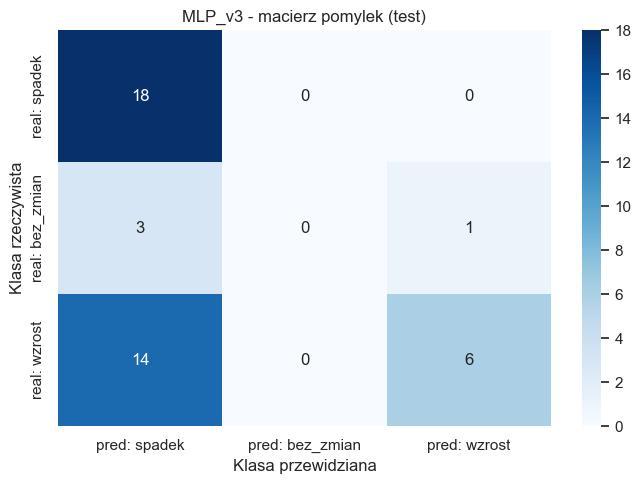

In [5]:
best_top_k = int(best["top_k"])
best_hidden = eval(best["hidden"])
best_alpha = float(best["alpha"])
best_thr = float(best["neutral_thr"])

sel_cols = select_top_k_by_mi(train_df[feature_cols], train_df["y_code"], best_top_k)

X_train, y_train = train_df[sel_cols], train_df["y_code"].to_numpy()
X_test, y_test = test_df[sel_cols], test_df["y_code"].to_numpy()

final_model = Pipeline(
    steps=[
        ("imp", SimpleImputer(strategy="median")),
        ("sc", StandardScaler()),
        (
            "mlp",
            MLPClassifier(
                hidden_layer_sizes=best_hidden,
                activation="relu",
                alpha=best_alpha,
                learning_rate_init=1e-3,
                max_iter=900,
                early_stopping=True,
                validation_fraction=0.15,
                n_iter_no_change=25,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
final_model.fit(X_train, y_train)

train_proba = final_model.predict_proba(X_train)
test_proba = final_model.predict_proba(X_test)
pred_train = predict_with_neutral_threshold(train_proba, best_thr)
pred_test = predict_with_neutral_threshold(test_proba, best_thr)

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train.fillna(0), y_train)
pred_dummy = dummy.predict(X_test.fillna(0))

metrics_df = pd.DataFrame(
    [
        metric_row("Dummy(most_frequent)", "test", y_test, pred_dummy),
        metric_row("MLP_v3", "train", y_train, pred_train),
        metric_row("MLP_v3", "test", y_test, pred_test),
    ]
)
display(metrics_df.round(4))

print(f"Uzyty neutral_thr: {best_thr:.2f}")
print("Raport klasyfikacji MLP_v3 (test):")
print(classification_report(y_test, pred_test, labels=CLASS_CODE_ORDER, target_names=CLASS_ORDER, zero_division=0))

cm = confusion_matrix(y_test, pred_test, labels=CLASS_CODE_ORDER)
cm_df = pd.DataFrame(cm, index=[f"real: {c}" for c in CLASS_ORDER], columns=[f"pred: {c}" for c in CLASS_ORDER])
display(cm_df)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("MLP_v3 - macierz pomylek (test)")
plt.xlabel("Klasa przewidziana")
plt.ylabel("Klasa rzeczywista")
plt.tight_layout()
plt.show()


In [6]:
search_path = model_dir / "stock_direction_v3_search_results.csv"
metrics_path = model_dir / "stock_direction_v3_metrics.csv"
preds_path = model_dir / "stock_direction_v3_test_predictions.csv"
features_path = model_dir / "stock_direction_v3_selected_features.csv"

search_df.to_csv(search_path, index=False)
metrics_df.to_csv(metrics_path, index=False)

preds_df = pd.DataFrame(
    {
        "date": test_df["date"].values,
        "y_true": y_test,
        "y_pred": pred_test,
        "proba_spadek": test_proba[:, 0],
        "proba_bez_zmian": test_proba[:, 1],
        "proba_wzrost": test_proba[:, 2],
    }
)
preds_df.to_csv(preds_path, index=False)
pd.DataFrame({"feature": sel_cols}).to_csv(features_path, index=False)

print(search_path)
print(metrics_path)
print(preds_path)
print(features_path)


..\data\equity_data\model_data\stock_direction_v3_search_results.csv
..\data\equity_data\model_data\stock_direction_v3_metrics.csv
..\data\equity_data\model_data\stock_direction_v3_test_predictions.csv
..\data\equity_data\model_data\stock_direction_v3_selected_features.csv
